# Transfer Learning on Human Influenza Data (ICL102)

This notebook applies the omicsTL transfer learning pipeline to the **ICL102 human influenza dataset**.
No simulation is performed — the models are trained directly on experimental multi-omics data.

## Experimental design

| Feature | Detail |
|---------|--------|
| Study | OMICS-LHV ICL102 — human *in vitro* influenza |
| Strains | FM (H1N1), AH1 (H1N1 pandemic), 691 (H3N2), Mock |
| Time points | 0 h, 3 h, 7 h, 12 h, 18 h, 24 h post-infection |
| Replicates | 5 per strain × time point |
| Omic layers | Peptide/proteomics, metabolomics, lipidomics (+) and lipidomics (−) |

## Source / target split

| Domain | Strains | n approx. |
|--------|---------|----------|
| **Source** | 691, AH1 + 3 mock reps/timepoint | ~77–78 |
| **Target** | FM + 2 mock reps/timepoint | ~42 |

**Response**: binary — 1 = virus-infected, 0 = mock.

The research question is whether knowledge from two influenza strains (source) improves
classification of a third strain (FM, target) when labelled target samples are scarce.

## Data location

Pre-processed source/target CSVs live in `viral_use_case/data/` inside this repository:

```
viral_use_case/data/
  source_pep.csv        (77 samples × 21 878 peptide features)
  target_pep.csv        (42 samples × 21 878 peptide features)
  source_metab.csv      (77 samples ×     80 metabolites)
  target_metab.csv      (42 samples ×     80 metabolites)
  source_lipidpos.csv   (77 samples ×    243 lipids, positive mode)
  target_lipidpos.csv   (42 samples ×    243 lipids, positive mode)
  source_lipidneg.csv   (77 samples ×    250 lipids, negative mode)
  target_lipidneg.csv   (42 samples ×    250 lipids, negative mode)
```

These were exported from the pmartR processed objects in `LHV_ICL102/Processed_Data/` using
`LHV_ICL102/Code/make_source_target.R`.  Features with zero variance in either domain were removed;
missing values were imputed with KNN (k = 10) **separately per domain** to prevent leakage.

## Outline
1. Data loading and EDA
2. Single-omic transfer learning (metabolomics — 80 features)
3. Multi-omics transfer learning (all 4 layers)
4. Results comparison

In [1]:
import pathlib
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch
from sklearn.model_selection import train_test_split

from omicstl.simulation_utils.data_utils import DatasetContainer
from omicstl.simulation_utils.model_utils import fit_dl_model, fit_rf_model

# ── paths ──────────────────────────────────────────────────────────────────────
# Works whether the kernel CWD is the repo root or the docs/ folder.
_candidates = [
    pathlib.Path("viral_use_case/data"),     # CWD = repo root
    pathlib.Path("../viral_use_case/data"),  # CWD = docs/
]
DATA_DIR = next((p.resolve() for p in _candidates if p.is_dir()), None)
assert DATA_DIR is not None, "Could not locate viral_use_case/data — run from repo root or docs/"

RESPONSE_COL = "response"
RANDOM_STATE = 42
TARGET_TEST_SIZE = 0.25   # fraction of target held out for evaluation

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Data directory: {DATA_DIR}")

Device: cpu
Data directory: /workspaces/timed-hpc/viral_use_case/data


---
## 1. Data loading and EDA

In [2]:
# ── omic manifest ──────────────────────────────────────────────────────────────
OMICS = {
    "peptide":    ("source_pep.csv",      "target_pep.csv"),
    "metab":      ("source_metab.csv",    "target_metab.csv"),
    "lipidpos":   ("source_lipidpos.csv", "target_lipidpos.csv"),
    "lipidneg":   ("source_lipidneg.csv", "target_lipidneg.csv"),
}

def load_omic(src_file: str, tgt_file: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Load source and target CSVs; ensure response is int64."""
    src = pd.read_csv(DATA_DIR / src_file, index_col=0)
    tgt = pd.read_csv(DATA_DIR / tgt_file, index_col=0)
    for df in (src, tgt):
        df[RESPONSE_COL] = df[RESPONSE_COL].astype(np.int64)
    return src, tgt

raw: dict[str, tuple[pd.DataFrame, pd.DataFrame]] = {
    name: load_omic(s, t) for name, (s, t) in OMICS.items()
}

# ── summary table ──────────────────────────────────────────────────────────────
rows = []
for name, (src, tgt) in raw.items():
    n_feat = src.shape[1] - 1
    rows.append({
        "Omic": name,
        "Source n": len(src),
        "Src infected": int(src[RESPONSE_COL].sum()),
        "Src mock": int((src[RESPONSE_COL] == 0).sum()),
        "Target n": len(tgt),
        "Tgt infected": int(tgt[RESPONSE_COL].sum()),
        "Tgt mock": int((tgt[RESPONSE_COL] == 0).sum()),
        "Features": n_feat,
    })

summary_df = pd.DataFrame(rows).set_index("Omic")
print("Dataset summary")
print(summary_df.to_string())

Dataset summary
          Source n  Src infected  Src mock  Target n  Tgt infected  Tgt mock  Features
Omic                                                                                  
peptide         77            59        18        42            30        12     21878
metab           78            60        18        42            30        12        80
lipidpos        78            60        18        42            30        12       243
lipidneg        78            60        18        42            30        12       250


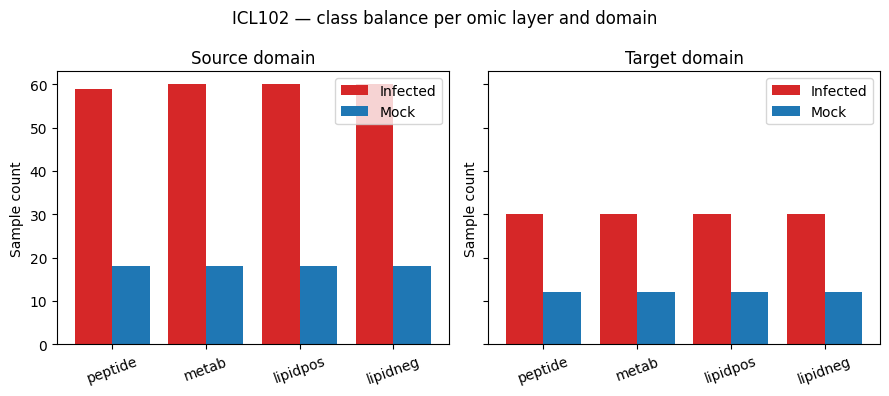

In [3]:
# ── class balance bar chart ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)

for ax, domain in zip(axes, ["source", "target"]):
    idx = 0 if domain == "source" else 1
    infected = [raw[n][idx][RESPONSE_COL].sum() for n in OMICS]
    mock     = [(raw[n][idx][RESPONSE_COL] == 0).sum() for n in OMICS]
    x = np.arange(len(OMICS))
    ax.bar(x - 0.2, infected, 0.4, label="Infected", color="#d62728")
    ax.bar(x + 0.2, mock,     0.4, label="Mock",     color="#1f77b4")
    ax.set_xticks(x)
    ax.set_xticklabels(list(OMICS.keys()), rotation=20)
    ax.set_title(f"{domain.capitalize()} domain")
    ax.legend()
    ax.set_ylabel("Sample count")

fig.suptitle("ICL102 — class balance per omic layer and domain", fontsize=12)
plt.tight_layout()
plt.show()

---
## 2. Single-omic transfer learning — metabolomics (80 features)

Metabolomics is used here for the single-omic showcase because its feature count (80) keeps
training times short.  The same pipeline runs on the peptide omic (~22 K features) with longer
wall-clock time.

### Model legend

#### Random Forest (TransferForest)

| `model_type` column | Training data | Description |
|---|---|---|
| `pred_source_full` | **Source only** | Source RF applied directly to target — no target labels used |
| `pred_0_full` | **Target only** | Plain `randomForest` on target train labels; no source knowledge |
| `pred_1_full` | **Target + source** | VI-transfer: source feature importances used as variable-sampling probs |
| `pred_2_full` | **Target + source** | Error-correction: RF trained on residuals of source predictions on target |
| `pred_3_full` | **Target + source** | Augmented features: source predictions appended to target features |
| `pred_ensemble_full` | **Target + source** | Weighted ensemble of m1–m3 only (equal weights unless a separate ensemble set is provided) |
| `*_full_val` | (same as above) | Same models, validation-set score adjustment applied |

#### MLP (TransferMLP)

| `model_id` column | Training data | Description |
|---|---|---|
| `target` | **Target + source** | Source pre-trained, then fine-tuned on target train split (transfer learning) |
| `target_nosource` | **Target only** | Trained only on target train labels; no source |

### Training / evaluation protocol

```
Source data  (78 samples) ──► train source model          (no split — all source used)
                                         │
                                         ▼
Target train (~31 samples) ──► adapt TL model  ──► evaluate on target test
Target train (~31 samples) ──► train target-only ──► evaluate on target test
                                         ▲
Target test  (~11 samples) ──────────────┘  (held-out; never seen during training)
```

- The split is **target-only**: 75% train / 25% test, stratified by response.
- Source data is never split — all 78 samples train the source model.
- Inside `fit_dl_model`, the target train split is further divided 90/10 internally for early stopping.

In [4]:
def make_container(
    source_df: pd.DataFrame,
    target_df: pd.DataFrame,
    view_column_groups: dict | None = None,
    scenario: int = 1,
    replicate: int = 1,
    test_size: float = 0.25,
) -> DatasetContainer:
    """Split target into train/test; source is used in full for training.

    Source data  → all samples used to train the source model (no split).
    Target train → used to adapt/fine-tune the TL model and train the target-only baseline.
    Target test  → held-out; used only for final evaluation of all models.
    """
    tgt_train, tgt_test = train_test_split(
        target_df,
        test_size=test_size,
        stratify=target_df[RESPONSE_COL],
        random_state=RANDOM_STATE,
    )
    container = DatasetContainer(
        source_data=source_df,
        target_data=tgt_train,        # target training split
        target_test_data=[tgt_test],  # held-out target test split
        id_tuple=(replicate, scenario),
        view_column_groups=view_column_groups,
    )
    container.set_response_column(RESPONSE_COL)
    return container


# ── build single-omic container (metabolomics) ─────────────────────────────────
src_metab, tgt_metab = raw["metab"]
container_metab = make_container(src_metab, tgt_metab)

print(container_metab)
print(f"\nSource (full, for training) : {container_metab.source_data.shape[0]} samples")
print(f"Target train (TL adapt)     : {container_metab.target_data.shape[0]} samples")
print(f"Target test  (held-out)     : {container_metab.target_test_data[0].shape[0]} samples")
print(f"Classification task         : {container_metab.is_classification()}")

DatasetContainer for ID (1, 1) with:
  Source data: (78, 81) (not split)
  Target data: (31, 81)
  Target test data: 1 datasets

Source (full, for training) : 78 samples
Target train (TL adapt)     : 31 samples
Target test  (held-out)     : 11 samples
Classification task         : True


In [5]:
# ── Random Forest TL — single omic ────────────────────────────────────────────
print("Fitting TransferForest (metabolomics) ...")
rf_results_metab, rf_model_metab = fit_rf_model(container_metab)
print("Done.")
print(rf_results_metab[["split", "model_type", "acc", "f1", "mcc", "roc_auc"]].to_string(index=False))

Fitting TransferForest (metabolomics) ...
Done.
 split             model_type      acc       f1       mcc  roc_auc
test_0       pred_source_full 0.363636 0.461538 -0.260875 0.916667
test_0   pred_source_full_val 0.272727 0.428571 -0.559017 0.916667
test_0            pred_0_full 0.454545 0.500000  0.038576 0.708333
test_0        pred_0_full_val 0.636364 0.714286  0.260875 0.708333
test_0            pred_1_full 0.636364 0.714286  0.260875 0.645833
test_0        pred_1_full_val 0.545455 0.666667 -0.038576 0.645833
test_0            pred_2_full 0.272727 0.000000  0.000000 0.791667
test_0        pred_2_full_val 0.272727 0.000000  0.000000 0.791667
test_0            pred_3_full 0.363636 0.533333 -0.462910 0.791667
test_0        pred_3_full_val 0.454545 0.571429 -0.149071 0.791667
test_0     pred_ensemble_full 0.454545 0.400000  0.288675 0.875000
test_0 pred_ensemble_full_val 0.363636 0.363636 -0.083333 0.875000


In [ ]:
# ── MLP TL — single omic ──────────────────────────────────────────────────────
param_grid_mlp = {
    "hidden_dim_base": [8, 16],
    "n_latent_dims":   [2, 3],
    "dropout":         [0.2],
    "source_epochs":   [300],
    "target_epochs":   [300],
    "lr":              [1e-3],
    "weight_decay":    [1e-4],
}

print("Fitting TransferMLP (metabolomics) ...")
mlp_results_metab, mlp_model_metab, mlp_nosrc_metab = fit_dl_model(
    data_container=container_metab,
    model_type="mult_mlp",
    torch_device=DEVICE,
    param_grid=param_grid_mlp,
)
print("Done.")
print(mlp_results_metab[["split", "model_id", "acc", "f1", "mcc", "roc_auc"]].to_string(index=False))

In [ ]:
# ── VAE TL — single omic ──────────────────────────────────────────────────────
param_grid_vae = {
    **param_grid_mlp,
    "z_dim_base": [4, 8],
    "var_beta":   [0.01],
}

print("Fitting TransferVAE (metabolomics) ...")
vae_results_metab, vae_model_metab, vae_nosrc_metab = fit_dl_model(
    data_container=container_metab,
    model_type="mult_vae",
    torch_device=DEVICE,
    param_grid=param_grid_vae,
)
print("Done.")
print(vae_results_metab[["split", "model_id", "acc", "f1", "mcc", "roc_auc"]].to_string(index=False))

In [ ]:
# ── collect single-omic results ───────────────────────────────────────────────
def label_results(df: pd.DataFrame, model_label: str) -> pd.DataFrame:
    df = df.copy()
    df["algorithm"] = model_label
    return df

single_omic_results = pd.concat([
    label_results(rf_results_metab,  "RF"),
    label_results(mlp_results_metab, "MLP"),
    label_results(vae_results_metab, "VAE"),
], ignore_index=True)

cols_show = ["algorithm", "model_type", "model_id", "acc", "f1", "mcc", "roc_auc"]
print("Single-omic (metabolomics) results")
print(single_omic_results[cols_show].to_string(index=False))

---
## 3. Multi-omics transfer learning

All four omic layers are combined into a single DataFrame.  Each omic's feature columns
receive an omic-specific prefix to avoid name collisions.  The `view_column_groups`
dictionary tells `DatasetContainer` which columns belong to which view, so that the
multi-view neural network (TransferMLP / TransferVAE) receives one encoder per omic.

In [8]:
def prefix_features(df: pd.DataFrame, prefix: str, response_col: str = RESPONSE_COL) -> pd.DataFrame:
    """Add omic prefix to all feature columns; leave response column unchanged."""
    rename_map = {
        c: f"{prefix}__{c}" for c in df.columns if c != response_col
    }
    return df.rename(columns=rename_map)


def build_multiomics_df(
    omic_dfs: dict[str, pd.DataFrame],
    response_col: str = RESPONSE_COL,
) -> tuple[pd.DataFrame, dict[str, list[str]]]:
    """Concatenate prefixed omic DataFrames side-by-side.

    Returns the combined DataFrame and a view_column_groups dict.
    All DataFrames must have the same index (sample IDs).
    """
    prefixed = {}
    view_cols: dict[str, list[str]] = {}
    for name, df in omic_dfs.items():
        p = prefix_features(df.drop(columns=[response_col]), name)
        prefixed[name] = p
        view_cols[name] = list(p.columns)

    # use the response from the first omic (they are identical across omics)
    first_df = next(iter(omic_dfs.values()))
    combined = pd.concat(
        [first_df[[response_col]]] + list(prefixed.values()),
        axis=1,
    )
    return combined, view_cols


# align samples: use the intersection of sample IDs across all omics
src_ids = set(raw["peptide"][0].index)
tgt_ids = set(raw["peptide"][1].index)
for name, (s, t) in raw.items():
    src_ids &= set(s.index)
    tgt_ids &= set(t.index)

print(f"Shared source samples: {len(src_ids)}")
print(f"Shared target samples: {len(tgt_ids)}")

src_omics = {name: s.loc[sorted(src_ids)] for name, (s, t) in raw.items()}
tgt_omics = {name: t.loc[sorted(tgt_ids)] for name, (s, t) in raw.items()}

src_multi, view_col_groups = build_multiomics_df(src_omics)
tgt_multi, _              = build_multiomics_df(tgt_omics)

print(f"\nCombined source shape : {src_multi.shape}")
print(f"Combined target shape : {tgt_multi.shape}")
print("Views:")
for v, cols in view_col_groups.items():
    print(f"  {v}: {len(cols)} features")

Shared source samples: 77
Shared target samples: 42

Combined source shape : (77, 22452)
Combined target shape : (42, 22452)
Views:
  peptide: 21878 features
  metab: 80 features
  lipidpos: 243 features
  lipidneg: 250 features


In [9]:
# ── build multi-omics DatasetContainer ────────────────────────────────────────
container_multi = make_container(
    source_df=src_multi,
    target_df=tgt_multi,
    view_column_groups=view_col_groups,
    scenario=2,
)
print(container_multi)

DatasetContainer for ID (1, 2) with:
  Source data: (77, 22452) (not split)
  Target data: (42, 22452)
  Target test data: 1 datasets


In [10]:
# ── Random Forest TL — multi-omics ────────────────────────────────────────────
print("Fitting TransferForest (multi-omics) ...")
rf_results_multi, rf_model_multi = fit_rf_model(container_multi)
print("Done.")
print(rf_results_multi[["split", "model_type", "acc", "f1", "mcc", "roc_auc"]].to_string(index=False))

Fitting TransferForest (multi-omics) ...
Done.
 split             model_type      acc       f1      mcc  roc_auc
test_0       pred_source_full 0.642857 0.693878 0.363053 0.851389
test_0   pred_source_full_val 0.523810 0.600000 0.075378 0.851389
test_0            pred_0_full 0.523810 0.500000 0.353553 1.000000
test_0        pred_0_full_val 0.690476 0.723404 0.521536 1.000000
test_0            pred_1_full 0.642857 0.666667 0.471405 1.000000
test_0        pred_1_full_val 0.785714 0.823529 0.632456 1.000000
test_0            pred_2_full 0.285714 0.000000 0.000000 0.700000
test_0        pred_2_full_val 0.285714 0.000000 0.000000 0.700000
test_0            pred_3_full 0.523810 0.500000 0.353553 1.000000
test_0        pred_3_full_val 0.690476 0.723404 0.521536 1.000000
test_0     pred_ensemble_full 0.500000 0.461538 0.330289 0.805556
test_0 pred_ensemble_full_val 0.500000 0.461538 0.330289 0.805556


In [ ]:
# ── MLP TL — multi-omics ──────────────────────────────────────────────────────
# Uses the same param_grid_mlp defined in the single-omic MLP cell above.
print("Fitting TransferMLP (multi-omics, one encoder per omic) ...")
mlp_results_multi, mlp_model_multi, mlp_nosrc_multi = fit_dl_model(
    data_container=container_multi,
    model_type="mult_mlp",
    torch_device=DEVICE,
    param_grid=param_grid_mlp,
)
print("Done.")
print(mlp_results_multi[["split", "model_id", "acc", "f1", "mcc", "roc_auc"]].to_string(index=False))

In [ ]:
# ── VAE TL — multi-omics ──────────────────────────────────────────────────────
# Uses the same param_grid_vae defined in the single-omic VAE cell above.
print("Fitting TransferVAE (multi-omics, one encoder per omic) ...")
vae_results_multi, vae_model_multi, vae_nosrc_multi = fit_dl_model(
    data_container=container_multi,
    model_type="mult_vae",
    torch_device=DEVICE,
    param_grid=param_grid_vae,
)
print("Done.")
print(vae_results_multi[["split", "model_id", "acc", "f1", "mcc", "roc_auc"]].to_string(index=False))

---
## 4. Results comparison

In [ ]:
# ── collate all results into one table ────────────────────────────────────────
def tag(df: pd.DataFrame, omic: str, algo: str) -> pd.DataFrame:
    df = df.copy()
    df["omic"] = omic
    df["algo"] = algo

    def _cond(row):
        mid   = str(row.get("model_id",   "")).lower()
        mtype = str(row.get("model_type", "")).lower()

        # ── RF: identify by model_type first (RF always sets model_id="target") ──
        base = mtype.replace("_full_val", "").replace("_full", "")
        if base == "pred_source":
            return "source-only"
        if base == "pred_0":
            return "target-only"
        if base in ("pred_1", "pred_2", "pred_3", "pred_ensemble"):
            return "target+source"

        # ── MLP / VAE: identified by model_id ────────────────────────────────
        if "nosource" in mid:
            return "target-only"
        if mid == "target":
            return "target+source"

        return mtype

    df["condition"] = df.apply(_cond, axis=1)
    return df

all_results = pd.concat([
    tag(rf_results_metab,  "metab", "RF"),
    tag(mlp_results_metab, "metab", "MLP"),
    tag(vae_results_metab, "metab", "VAE"),
    tag(rf_results_multi,  "multi", "RF"),
    tag(mlp_results_multi, "multi", "MLP"),
    tag(vae_results_multi, "multi", "VAE"),
], ignore_index=True)

# Best RF TL model: pick from m1, m2, m3, OR ensemble — whichever has highest MCC.
# All four are pure TL models (m0/target-only excluded).
TL_MODELS = {"pred_1", "pred_2", "pred_3", "pred_ensemble"}

def best_tl_row(group: pd.DataFrame) -> pd.DataFrame:
    tl_mask   = group["model_type"].str.replace("_full_val","").str.replace("_full","").isin(TL_MODELS)
    full_mask  = group["model_type"].str.endswith("_full") & ~group["model_type"].str.endswith("_full_val")
    candidates = group[tl_mask & full_mask]
    if candidates.empty:
        return candidates
    best = candidates.loc[[candidates["mcc"].idxmax()]].copy()
    # annotate which model won
    best["best_rf_tl_model"] = best["model_type"].str.replace("_full_val","").str.replace("_full","")
    return best

rf_tl_best = (
    all_results[
        (all_results["algo"] == "RF") &
        (all_results["condition"] == "target+source")
    ]
    .groupby(["omic", "algo"], group_keys=False)
    .apply(best_tl_row)
    .assign(condition="best TL (RF)")
)

print("Best RF TL model per omic:")
print(rf_tl_best[["omic", "best_rf_tl_model", "acc", "f1", "mcc", "roc_auc"]].to_string(index=False))

# Build final comparison table
keep_conditions = ["source-only", "target-only"]
dl_tl = all_results[
    (all_results["algo"].isin(["MLP", "VAE"])) &
    (all_results["condition"] == "target+source")
].copy()
dl_tl["condition"] = dl_tl["algo"] + " TL"

compare = pd.concat([
    all_results[all_results["condition"].isin(keep_conditions)],
    dl_tl,
    rf_tl_best,
], ignore_index=True)

cols_disp = ["omic", "algo", "condition", "acc", "f1", "mcc", "roc_auc"]
print("\nFull comparison table:")
print(compare[cols_disp].sort_values(["omic", "algo", "condition"]).to_string(index=False))

In [ ]:
# ── bar chart ─────────────────────────────────────────────────────────────────
plot_conditions = [
    "source-only",
    "target-only",
    "best TL (RF)",
    "MLP TL",
    "VAE TL",
]
cond_colors = {
    "source-only":  "#ff7f0e",
    "target-only":  "#d62728",
    "best TL (RF)": "#2ca02c",
    "MLP TL":       "#17becf",
    "VAE TL":       "#8c564b",
}

plot_df = (
    compare[compare["condition"].isin(plot_conditions)]
    .groupby(["omic", "algo", "condition"], as_index=False)
    .agg(acc=("acc", "max"), f1=("f1", "max"), mcc=("mcc", "max"), roc_auc=("roc_auc", "max"))
)
plot_df["label"] = plot_df["omic"] + "\n" + plot_df["algo"]

metrics = [("acc", "Accuracy"), ("f1", "F1 score"), ("mcc", "MCC"), ("roc_auc", "ROC-AUC")]
labels_all = plot_df["label"].unique()
x = np.arange(len(labels_all))
n_cond = len(plot_conditions)
width = 0.15

fig, axes = plt.subplots(1, len(metrics), figsize=(20, 4))
for ax, (metric, metric_label) in zip(axes, metrics):
    for i, cond in enumerate(plot_conditions):
        sub = plot_df[plot_df["condition"] == cond].set_index("label").reindex(labels_all)
        vals = sub[metric].fillna(0).values
        ax.bar(x + (i - n_cond / 2 + 0.5) * width, vals, width,
               color=cond_colors[cond], label=cond)
    ax.set_xticks(x)
    ax.set_xticklabels(labels_all, fontsize=7)
    ax.set_title(metric_label, fontsize=9)
    ax.set_ylim(0, 1.05)

handles, lbls = axes[0].get_legend_handles_labels()
fig.legend(handles, lbls, loc="upper center", ncol=5, fontsize=8, bbox_to_anchor=(0.5, 1.06))
fig.suptitle("ICL102 influenza — model comparison (held-out target test set)\n"
             "RF 'best TL' = best of m1, m2, m3, ensemble by MCC", fontsize=9, y=1.12)
plt.tight_layout()
plt.show()

In [ ]:
# ── summary table: best result per omic × algorithm ───────────────────────────
summary = (
    all_results
    .loc[all_results["condition"].isin(plot_conditions), ["omic", "algo", "condition", "acc", "f1", "mcc", "roc_auc"]]
    .pivot_table(index=["omic", "algo"], columns="condition", values=["acc", "f1", "mcc", "roc_auc"])
    .round(3)
)
print(summary.to_string())